In [416]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay

In [417]:
def report(y_true,y_pred):
    report = classification_report(y_true,y_pred)
    conf_matrix = confusion_matrix(y_true,y_pred)
    disp = ConfusionMatrixDisplay(conf_matrix)
    disp.plot()
    print(report)

In [418]:
def model_training(list_of_models,X_train,y_train,X_test,y_test):
    for model in list_of_models:
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        print(f"Model: {model.__class__.__name__}")
        report(y_test,y_pred)


In [419]:
df = pd.read_csv('TCA_Cleaned.csv')

In [420]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
237,238,1,2,"Collyer, Miss. Marjorie ""Lottie""",female,8.0,3,C.A. 31921,26.2500,S,Miss
273,274,0,1,"Natsch, Mr. Charles H",male,37.0,2,PC 17596,29.7000,C,Mr
480,481,0,3,"Goodwin, Master. Harold Victor",male,9.0,8,CA 2144,46.9000,S,Master
409,410,0,3,"Lefebre, Miss. Ida",female,NaN,5,4133,25.4667,S,Miss
45,46,0,3,"Rogers, Mr. William John",male,NaN,1,S.C./A.4. 23567,8.0500,S,Mr


In [421]:
df["Age"] = df["Age"].fillna(
    df.groupby(["Sex", "Pclass"])["Age"].transform("median")
)

In [422]:
df['Age'].isnull().sum()

np.int64(0)

In [423]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
FamSize        0
Ticket         0
Fare           0
Embarked       2
Title          1
dtype: int64

In [424]:
df.dropna(inplace=True)

In [425]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
FamSize        0
Ticket         0
Fare           0
Embarked       0
Title          0
dtype: int64

In [426]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
374,375,0,3,"Palsson, Miss. Stina Viola",female,3.0,5,349909,21.0750,S,Miss
62,63,0,1,"Harris, Mr. Henry Birkhardt",male,45.0,2,36973,83.4750,S,Mr
83,84,0,1,"Carrau, Mr. Francisco M",male,28.0,1,113059,47.1000,S,Mr
93,94,0,3,"Dean, Mr. Bertram Frank",male,26.0,4,C.A. 2315,20.5750,S,Mr
318,319,1,1,"Wick, Miss. Mary Natalie",female,31.0,3,36928,164.8667,S,Miss


## Using StandardScaler on age and Fare columns
## OneHotencoding the sex,Title and embarked columns

In [427]:
numerical_features = ['Age', 'Fare']
scaler = StandardScaler()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,2,A/5 21171,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,2,PC 17599,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,1,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,2,113803,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,1,373450,8.0500,S,Mr


In [428]:
df['Title'].value_counts()

Title
Mr          517
Miss        181
Mrs         124
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Don           1
Mme           1
Ms            1
Sir           1
Lady          1
Capt          1
Jonkheer      1
Name: count, dtype: int64

In [429]:
categorical_features = ['Sex', 'Embarked', 'Title']
Sex = {'male':0,"female":1}
embarked = {'S':0,'C':1,'Q':2}
title = {'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Other':4}
def map_values(value):
    value['Sex'] = Sex[value['Sex']]
    value['Embarked'] = embarked[value['Embarked']]
    try: 
        value['Title'] = title[value['Title']]
    except KeyError:
        value['Title'] = 4
    return value
df[['Sex','Embarked','Title']] = df[['Sex','Embarked','Title']].apply(map_values, axis=1)

In [430]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,FamSize,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,2,A/5 21171,7.2500,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,2,PC 17599,71.2833,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,1,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,2,113803,53.1000,0,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,1,373450,8.0500,0,0


In [431]:
xgbModel = XGBClassifier()
svmModel = SVC(kernel='linear',probability=True)
list_of_models = [xgbModel,svmModel]
x = df.drop(columns=['Survived','Name','Ticket','PassengerId'], axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1,random_state=42)
scaler.fit_transform(X_train[numerical_features])
scaler.transform(X_test[numerical_features])

array([[-8.18651901e-02, -4.99631732e-01],
       [-1.12130221e+00,  1.83991396e+00],
       [-1.12130221e+00, -4.28962915e-01],
       [ 6.66258131e-02, -3.92281887e-01],
       [-8.24320206e-01,  9.98146651e-01],
       [ 1.40871315e-01, -5.01283974e-01],
       [-3.04601695e-01, -3.92281887e-01],
       [-3.04601695e-01, -4.95547022e-01],
       [ 7.34835327e-01,  1.64972462e+00],
       [ 6.66258131e-02,  1.55671715e+00],
       [-5.64460951e-01,  7.87444052e-01],
       [-3.78847197e-01, -3.32826203e-01],
       [ 1.62578135e+00, -5.16321047e-01],
       [-2.30356193e-01, -3.61944885e-01],
       [-7.61968852e-03, -4.65646029e-01],
       [-8.18651901e-02, -1.93574733e-01],
       [ 1.55153585e+00,  1.55671715e+00],
       [-3.04601695e-01, -5.12670259e-01],
       [ 1.03181733e+00, -5.28925652e-01],
       [-3.04601695e-01, -4.98763888e-01],
       [-9.72811209e-01,  3.14927827e-01],
       [ 4.37853321e-01,  4.83907139e-01],
       [ 9.57571832e-01, -4.88157828e-01],
       [ 8.

In [432]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((799, 7), (799,), (89, 7), (89,))

In [433]:
X_train.columns

Index(['Pclass', 'Sex', 'Age', 'FamSize', 'Fare', 'Embarked', 'Title'], dtype='object')

Model: XGBClassifier
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        60
           1       0.73      0.83      0.77        29

    accuracy                           0.84        89
   macro avg       0.82      0.84      0.83        89
weighted avg       0.85      0.84      0.85        89

Model: SVC
              precision    recall  f1-score   support

           0       0.92      0.82      0.87        60
           1       0.69      0.86      0.77        29

    accuracy                           0.83        89
   macro avg       0.81      0.84      0.82        89
weighted avg       0.85      0.83      0.84        89



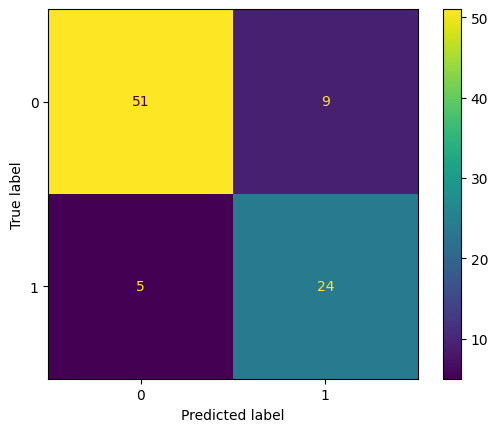

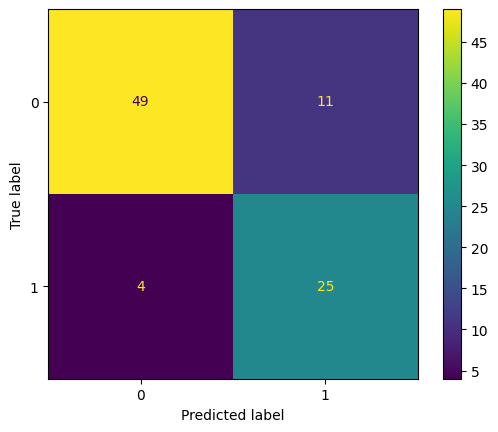

In [434]:
model_training(list_of_models,X_train,y_train,X_test,y_test)

In [435]:
xgbFI = xgbModel.feature_importances_
svmFI = svmModel.coef_[0]

In [436]:
columns = X_train.columns

Text(0.5, 1.0, 'SVM Feature Importance')

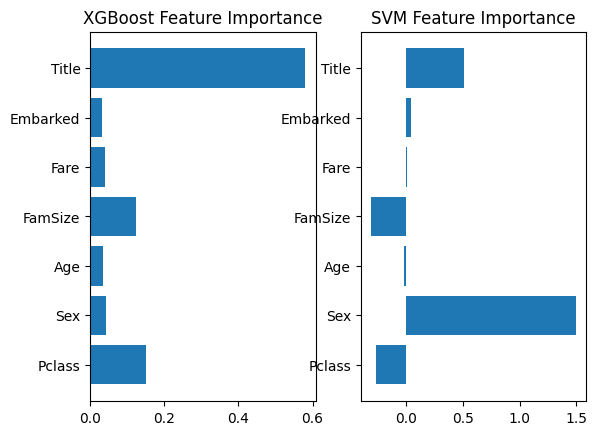

In [437]:
ax = plt.subplot(1,2,1)
ax.barh(columns,xgbFI)
ax.set_title("XGBoost Feature Importance")
ax = plt.subplot(1,2,2)
ax.barh(columns,svmFI)
ax.set_title("SVM Feature Importance")

In [438]:
X_train = df.drop(columns=['Survived','Name','Ticket','PassengerId'], axis=1)
y_train = df['Survived']

In [439]:
scaler.fit_transform(X_train[numerical_features])
X_train.head()

,Pclass,Sex,Age,FamSize,Fare,Embarked,Title
0,3,0,22.0,2,7.2500,0,0
1,1,1,38.0,2,71.2833,1,2
2,3,1,26.0,1,7.9250,0,1
3,1,1,35.0,2,53.1000,0,2
4,3,0,35.0,1,8.0500,0,0


              precision    recall  f1-score   support

           0       0.98      1.00      0.99        60
           1       1.00      0.97      0.98        29

    accuracy                           0.99        89
   macro avg       0.99      0.98      0.99        89
weighted avg       0.99      0.99      0.99        89



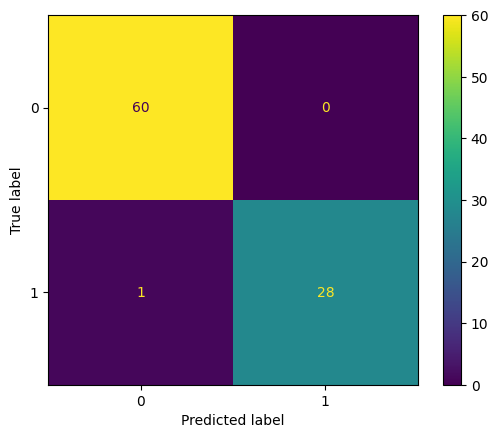

In [440]:
XgbClassifier = XGBClassifier()
XgbClassifier.fit(X_train,y_train)
y_pred = XgbClassifier.predict(X_test)
report(y_test,y_pred)

In [441]:
test_data = pd.read_csv('test.csv')

In [442]:
test_data.sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
352,1244,2,"Dibden, Mr. William",male,18.0,0,0,S.O.C. 14879,73.5000,NaN,S
391,1283,1,"Lines, Mrs. Ernest H (Elizabeth Lindsey James)",female,51.0,0,1,PC 17592,39.4000,D28,S
227,1119,3,"McNeill, Miss. Bridget",female,NaN,0,0,370368,7.7500,NaN,Q
315,1207,3,"Hagardon, Miss. Kate",female,17.0,0,0,AQ/3. 30631,7.7333,NaN,Q
221,1113,3,"Reynolds, Mr. Harold J",male,21.0,0,0,342684,8.0500,NaN,S


In [443]:
test_data['Age'] = test_data['Age'].fillna(
    test_data.groupby(["Sex", "Pclass"])["Age"].transform("median")
)

In [444]:
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].mean())

In [445]:
test_data.drop('Cabin',axis=1,inplace=True)

In [446]:
test_data.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [447]:
test_data["FamSize"] = test_data["SibSp"] + test_data["Parch"] + 1
test_data.drop(columns=['SibSp','Parch','Ticket'],inplace=True)
test_data.sample(2)

,PassengerId,Pclass,Name,Sex,Age,Fare,Embarked,FamSize
344,1236,3,"van Billiard, Master. James William",male,24.0,14.500,S,3
375,1267,1,"Bowen, Miss. Grace Scott",female,45.0,262.375,C,1


In [448]:
test_data["Title"] = test_data["Name"].str.extract(r", (\w+)\.")

In [449]:
test_data.sample(2)

,PassengerId,Pclass,Name,Sex,Age,Fare,Embarked,FamSize,Title
308,1200,1,"Hays, Mr. Charles Melville",male,55.0,93.5,S,3,Mr
137,1029,2,"Schmidt, Mr. August",male,26.0,13.0,S,1,Mr


In [450]:
test_data[numerical_features] = scaler.transform(test_data[numerical_features])
test_data[['Sex','Embarked','Title']] = test_data[['Sex','Embarked','Title']].apply(map_values, axis=1)
test_data.sample(2)

,PassengerId,Pclass,Name,Sex,Age,Fare,Embarked,FamSize,Title
267,1159,3,"Warren, Mr. Charles William",0,-0.381103,-0.493022,0,1,0
245,1137,1,"Kenyon, Mr. Frederick R",0,0.900219,0.399225,0,2,0


In [451]:
X_data = test_data[X_train.columns]

In [452]:
X_data

,Pclass,Sex,Age,FamSize,Fare,Embarked,Title
0,3,0,0.410301,1,-0.487400,2,0
1,3,1,1.352450,2,-0.504097,0,2
2,2,0,2.483028,1,-0.449983,2,0
3,3,0,-0.154988,1,-0.470622,0,0
4,3,1,-0.531847,3,-0.397631,0,2
...,...,...,...,...,...,...,...
413,3,0,-0.381103,1,-0.482955,0,0
414,1,1,0.749475,1,1.547695,1,4
415,3,0,0.711789,1,-0.499063,0,0
416,3,0,-0.381103,1,-0.482955,0,0


In [453]:
y_pred = model.predict(X_data)

In [454]:
final_submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': y_pred
})

In [455]:
final_submission.to_csv('Submission.csv',index=False)